In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Funcoes.Funcoes_medidas import media,mediana,moda
from Funcoes.Funcoes_analises import analisar_coluna,analisar_correlação_spearman
from Funcoes.Funcoes_tratar import tratar,remover_duplicados


# Abrindo Dataset e Tirando Duplicatas

In [24]:
df = pd.read_csv(r'Dataset\german_credit_data.csv',index_col=0)
df_sem_duplicados = remover_duplicados(df)
df_tratado = tratar(df_sem_duplicados)

Não foram encontrados dados duplicados.

Convertendo tipos de dados: Mapeando coluna JOB...
Foram identificados 183 valores NaN na coluna 'Saving accounts'.
TRATANDO Saving accounts...

Coluna 'Saving accounts' tratada com 'No account'!

Foram identificados 394 valores NaN na coluna 'Checking account'.
TRATANDO Checking account...

Coluna 'Checking account' tratada com 'No account'!

Normalizando coluna 'Credit amount'...
Coluna 'Credit amount' normalizada com sucesso!
Criando coluna 'Risk' para numérica...
Coluna 'Risk' convertida para numérica (Risk_num) com sucesso!


# ANALISES NECESSARIAS

Média de Duração: 20.90
Mediana de Duração: 18.0


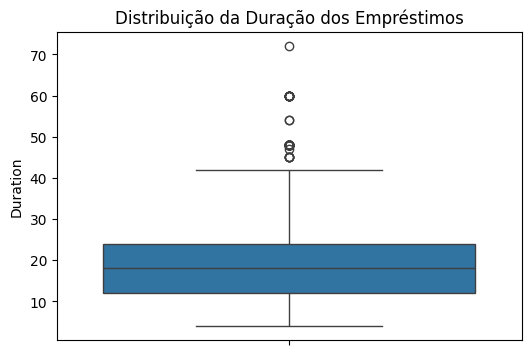

In [25]:
media_duration = media(df_tratado,'Duration')
mediana_duration = mediana(df_tratado,'Duration')

print(f"Média de Duração: {media_duration:.2f}")
print(f"Mediana de Duração: {mediana_duration}")

plt.figure(figsize=(6, 4))
sns.boxplot(y='Duration', data=df_tratado)
plt.title('Distribuição da Duração dos Empréstimos')
plt.show()

In [26]:
colunas_numericas = ['Age', 'Duration', 'Credit amount']
matriz_correlacao = df_tratado[colunas_numericas].corr(method='spearman')

print("Matriz de Correlação (Spearman):")
display(matriz_correlacao)

Matriz de Correlação (Spearman):


,Age,Duration,Credit amount
Age,1.000000,-0.036316,0.026298
Duration,-0.036316,1.000000,0.624709
Credit amount,0.026298,0.624709,1.000000


# Analise Geral Das Colunas

In [27]:
for coluna in df_tratado.columns:
        analisar_coluna(df_tratado, coluna)

------------------AGE------------------
Moda: 27
Média: 35.55
Mediana: 33.0

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 27.0 | Q2: 33.0 | Q3: 42.0

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 11.38
Variância: 129.40
Amplitude Total: 56

------------------SEX------------------
Moda: male

------------------JOB------------------
Moda: skilled

------------------HOUSING------------------
Moda: own

------------------SAVING ACCOUNTS------------------
Moda: little

------------------CHECKING ACCOUNT------------------
Moda: No account

------------------CREDIT AMOUNT------------------
Moda: 1258
Média: 3271.26
Mediana: 2319.5

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 1365.5 | Q2: 2319.5 | Q3: 3972.25

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 2822.74
Variância: 7967843.47
Amplitude Total: 18174

------------------DURATION------------------
Moda: 24
Média: 20.90
Mediana: 18.0

--- MEDIDAS DE POSIÇÃO ---

Quartis: Q1: 12.0 | Q2: 18.0 | Q3: 24.0

--- MEDIDAS DE DISPERSÃO ---

Desvio Padrão: 1

# HIPOTESE 1


--- RESULTADO HIPÓTESE 1 ---


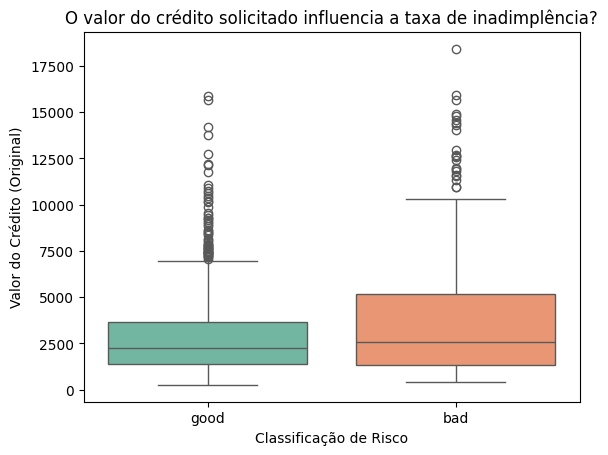


ANÁLISE DE CORRELAÇÃO (Spearman)
Relação entre Credit amount_normalizado e Risk_num: 0.0871

INTERPRETAÇÃO: Existe uma correlação positiva. Quanto MAIOR o crédito, MAIOR o risco.


In [28]:
sns.boxplot(
    x='Risk', 
    y='Credit amount', 
    data=df_tratado, 
    palette='Set2', 
    hue='Risk',     
    legend=False     
)

print("\n--- RESULTADO HIPÓTESE 1 ---")
plt.title('O valor do crédito solicitado influencia a taxa de inadimplência?')

plt.xlabel('Classificação de Risco')
plt.ylabel('Valor do Crédito (Original)')

plt.show()

analisar_correlação_spearman(df_tratado, 'Credit amount_normalizado', 'Risk_num') 

# HIPOTESE 2


--- RESULTADO HIPÓTESE 2 ---


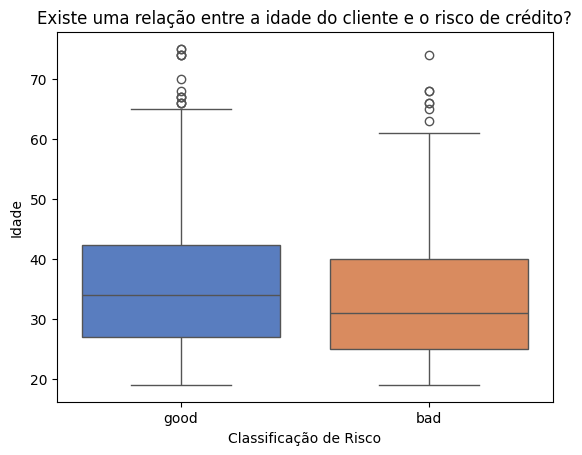


ANÁLISE DE CORRELAÇÃO (Spearman)
Relação entre Age e Risk_num: -0.1122

INTERPRETAÇÃO: Não há evidência de que o valor alto aumente o risco nesta base.


In [29]:
sns.boxplot(
    x='Risk', 
    y='Age', 
    data=df_tratado, 
    palette='muted', 
    hue='Risk',       
    legend=False      
)

print("\n--- RESULTADO HIPÓTESE 2 ---")
plt.title('Existe uma relação entre a idade do cliente e o risco de crédito?')
plt.xlabel('Classificação de Risco')
plt.ylabel('Idade')

plt.show()

analisar_correlação_spearman(df_tratado, 'Age', 'Risk_num') 

# HIPOTESE 3

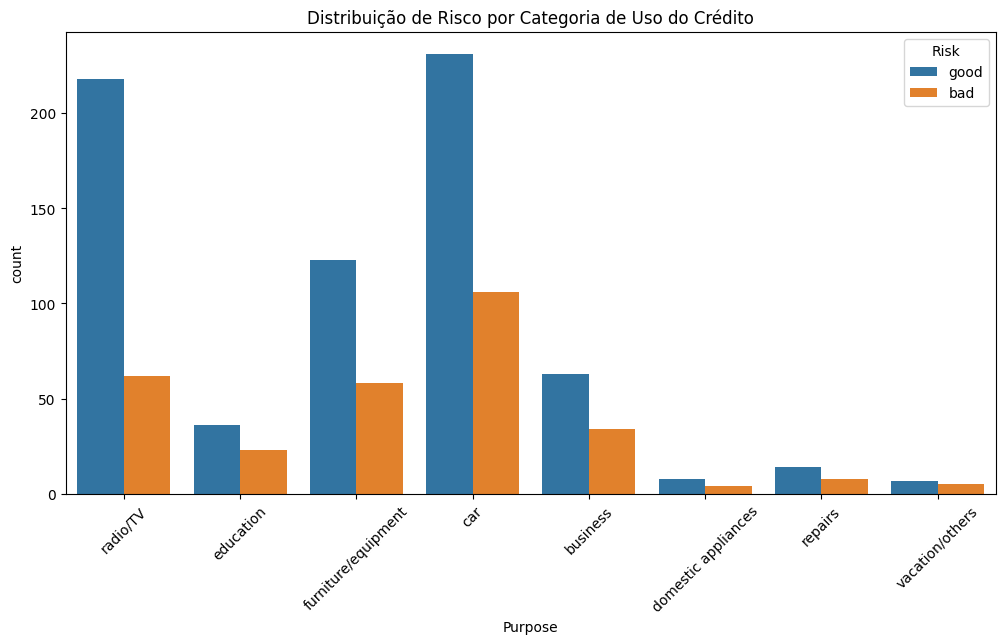

In [30]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Purpose', hue='Risk', data=df_tratado)

plt.title('Hipótese 3: Qual o propósito de empréstimo que apresenta o maior risco médio?')

plt.xticks(rotation=45)
plt.title('Distribuição de Risco por Categoria de Uso do Crédito')

plt.show()

# HIPOTESE 4

In [31]:
df_tratado['Categoria da duração'] = df_tratado['Duration'].apply(
    lambda x: 'Curta (<18m)' if x < 18 else 'Longa (>=18m)'
)

df_baixo_saldo = df_tratado[df_tratado['Checking account'] == 'little'].copy()

analise_h4 = df_baixo_saldo.groupby('Categoria da duração')['Risk_num'].mean() * 100

print("\n--- RESULTADO HIPÓTESE 4 ---")
print(f"Taxa de Inadimplência (Saldo Baixo + Duração Curta): {analise_h4['Curta (<18m)']:.2f}%")
print(f"Taxa de Inadimplência (Saldo Baixo + Duração Longa): {analise_h4['Longa (>=18m)']:.2f}%")



--- RESULTADO HIPÓTESE 4 ---
Taxa de Inadimplência (Saldo Baixo + Duração Curta): 34.86%
Taxa de Inadimplência (Saldo Baixo + Duração Longa): 58.79%


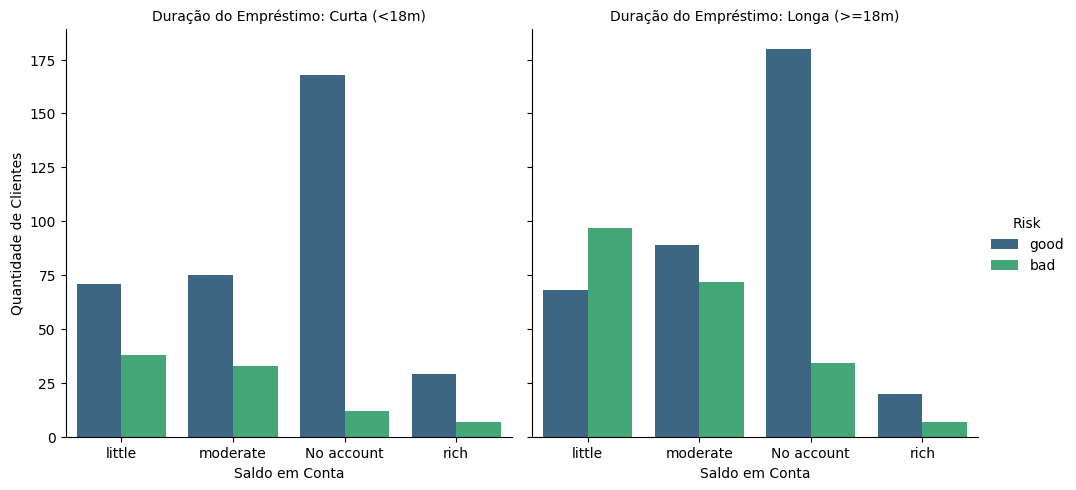

In [32]:
grafico_hipotese_4 = sns.catplot(
    data=df_tratado, 
    x="Checking account", 
    hue="Risk", 
    col="Categoria da duração", 
    kind="count", 
    palette="viridis"
)

grafico_hipotese_4.set_axis_labels("Saldo em Conta", "Quantidade de Clientes")
grafico_hipotese_4.set_titles("Duração do Empréstimo: {col_name}")

plt.show()

# HIPOTESE 5

In [33]:
media_credito = df_tratado['Credit amount'].mean()

df_tratado['Faixa de Valor'] = df_tratado['Credit amount'].apply(
    lambda x: 'Acima da Média' if x > media_credito else 'Abaixo da Média'
)

df_moradia = df_tratado[df_tratado['Housing'] == 'own'].copy()

analise_h5 = df_moradia.groupby('Faixa de Valor')['Risk_num'].mean() * 100

print("\n--- RESULTADO HIPÓTESE 5 (Clientes com Casa Própria) ---")
print(f"Média Global de Crédito: {media_credito:.2f}")
print(f"Taxa de Risco - Pedidos Abaixo da Média: {analise_h5['Abaixo da Média']:.2f}%")
print(f"Taxa de Risco - Pedidos Acima da Média: {analise_h5['Acima da Média']:.2f}%")


--- RESULTADO HIPÓTESE 5 (Clientes com Casa Própria) ---
Média Global de Crédito: 3271.26
Taxa de Risco - Pedidos Abaixo da Média: 23.09%
Taxa de Risco - Pedidos Acima da Média: 32.46%


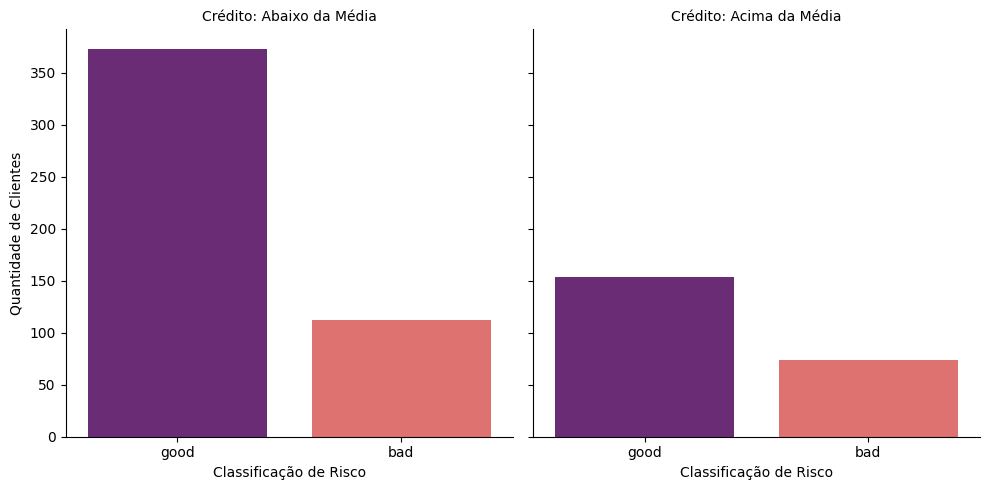

In [34]:
grafico_hipotese_5 = sns.catplot(
    data=df_moradia, 
    x="Risk", 
    col="Faixa de Valor", 
    kind="count", 
    palette="magma",
    hue="Risk",
    legend=False
)

grafico_hipotese_5.set_axis_labels("Classificação de Risco", "Quantidade de Clientes")
grafico_hipotese_5.set_titles("Crédito: {col_name}")

plt.show()